# Generative Modeling Foundations

## Start with the goal: create a new observation rather than only label one

A classifier receives an observation and predicts a label. A generative system produces an observation, such as a numerical measurement, image, sound, or token sequence. To do this usefully, it needs a sampling procedure whose outputs reflect the patterns and variation of the target data.

Think of a collection of measurements with two common regimes. A single average may fall between the regimes where almost no observations occur. A sampler should reflect how frequently each regime appears and how observations vary within it, rather than repeatedly output the average.

A **distribution** describes possible values and their relative probabilities or densities. A learned generative model tries to fit a distribution or a useful sampling procedure from data. The [code companion](37_Generative_Modeling_Foundations.ipynb) begins one step earlier: it samples from a distribution whose parameters are already known.

We will calculate that distribution, draw examples, derive its mean and variance, and compare learning objectives. This separates the mechanics of sampling from the evidence needed to show that a learned model captured something useful.


## Distinguish data, a model, and a sample

| Quantity | Meaning | What is available? |
| --- | --- | --- |
| $p_{data}(x)$ | The source distribution of interest | Usually only observed examples |
| $p_\theta(x)$ | A parameterized model distribution | Defined or approximated by the model |
| $x\sim p_\theta$ | A generated observation | One random outcome |
| Training dataset | Finite observations | A sample of the source, not the whole source |

A plausible individual output does not show that the distribution is correct. A model might produce a few attractive outputs while missing rare cases, reproducing training examples, or assigning the wrong frequencies to common patterns.

The goal depends on the task. A simulation may need correct statistical variation; a conditional generator may need to follow an input condition; a representation model may prioritize useful latent features. Define the behavior you want to assess before selecting a family of generative models.


## Write the companion's mixture precisely

Let latent component $c$ be zero with probability 0.30 and one with probability 0.70. Conditional on $c$, draw:

$$x=\mu_c+0.5\epsilon,\qquad\epsilon\sim\mathcal N(0,1),$$

with $\mu_0=-2$ and $\mu_1=2$. The marginal density is:

$$p(x)=0.30\,\mathcal N(x;-2,0.25)+0.70\,\mathcal N(x;2,0.25).$$

The last argument denotes variance, so standard deviation 0.5 becomes variance 0.25.

| Component | Probability | Mean | Standard deviation |
| --- | --- | --- | --- |
| 0 | 0.30 | -2 | 0.5 |
| 1 | 0.70 | 2 | 0.5 |

The code draws `component` from a Bernoulli distribution with probability 0.7 of value one, then uses that ID to select a center. Reversing the component weights would change the sample distribution even though the two peak locations remain the same.


## See the density rather than only its average

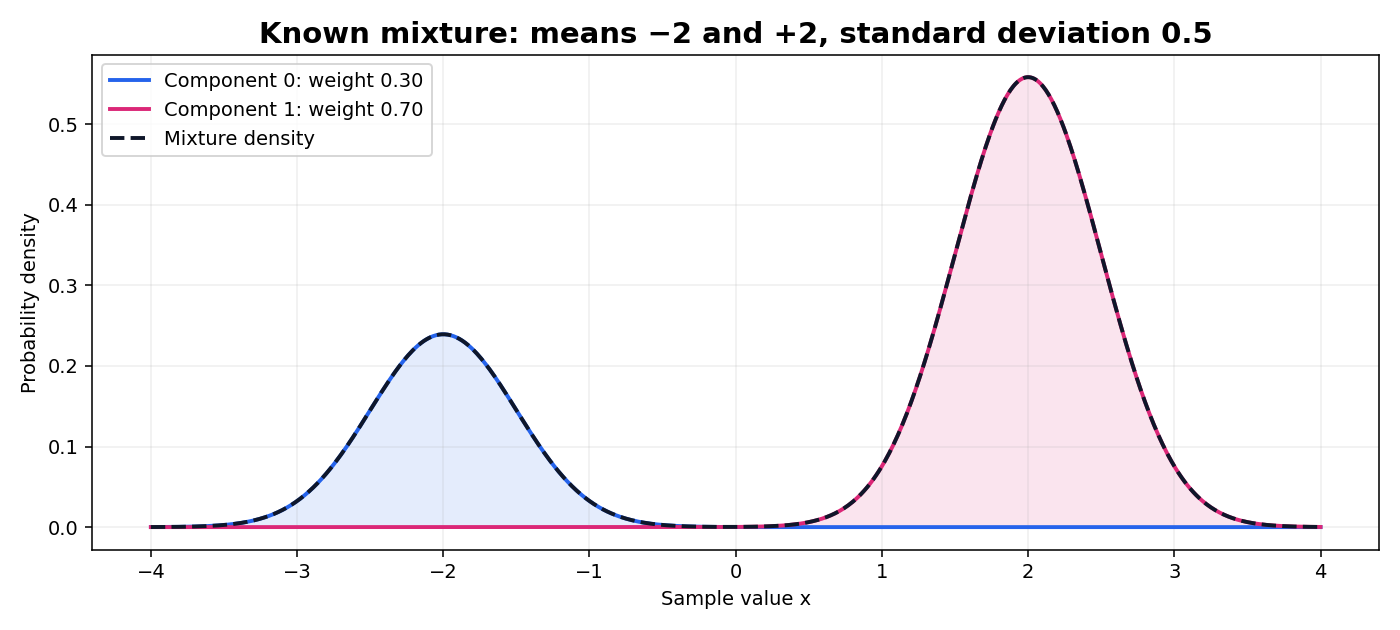

The density's two weighted peaks describe likely regions of values. The height of a continuous density is not the probability of one exact real number. Interval probability is the area under the curve over that interval.

At x equal to two, the density is approximately 0.558519; at x equal to minus two it is approximately 0.239365. The other component's contribution at either center is tiny because the centers are eight component standard deviations apart.

At zero, both components are far from their means, so the density is about 0.000268. The region between the peaks is much less likely than either peak region.

This is why plotting only a mean can conceal the structure. The distribution is not centered around one dense cluster even though its numerical expectation is well-defined. A model that always generates near the expectation would fail to capture the two regimes.


## Draw a sample in two stages

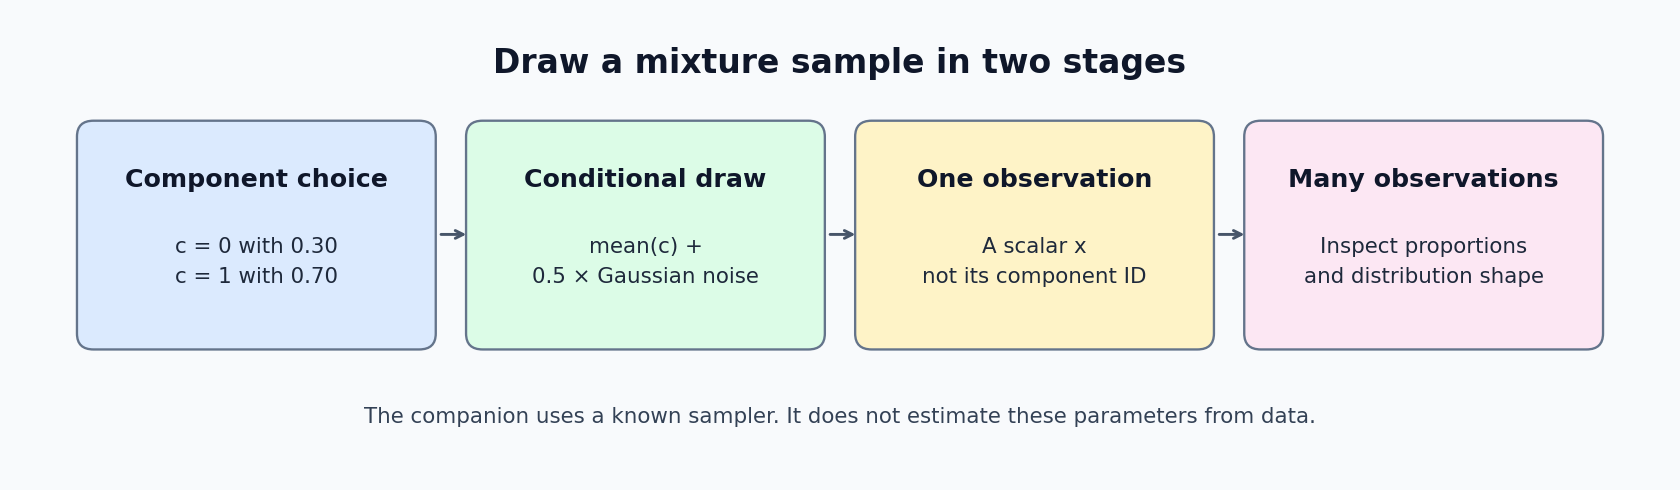

For a hand sampler, draw a uniform $u$ from zero to one. Choose component zero if $u<0.3$ and component one otherwise. Then draw an independent standard-normal value $\epsilon$.

| Selected $u$ | Component | Selected $\epsilon$ | Generated $x$ |
| --- | --- | --- | --- |
| 0.10 | 0 | 1.0 | $-2+0.5(1)=-1.5$ |
| 0.90 | 1 | -1.0 | $2+0.5(-1)=1.5$ |
| 0.50 | 1 | 0.2 | $2+0.5(0.2)=2.1$ |

These are illustrative random outcomes, not the exact companion's RNG trace. The uniform-threshold construction and its Bernoulli construction define the same component probabilities.

The component is a latent variable if the dataset contains only $x$. The code retains it because the sampling mechanism is known, allowing direct checks of frequencies and conditional means. Learning from unlabeled observed samples would not ordinarily receive those true component IDs for free.


## Derive the expected mean and variance

The expected value is the weighted component mean:

$$\mathbb E[x]=0.3(-2)+0.7(2)=0.8.$$

Total variance separates variation within components from variation between their means:

$$\operatorname{Var}(x)=\mathbb E[\operatorname{Var}(x\mid c)]+\operatorname{Var}(\mathbb E[x\mid c]).$$

| Contribution | Calculation | Result |
| --- | --- | --- |
| Within-component variance | $0.3(0.25)+0.7(0.25)$ | 0.25 |
| Between-component variance | $0.3(-2-0.8)^2+0.7(2-0.8)^2$ | 3.36 |
| Total variance | $0.25+3.36$ | 3.61 |
| Total standard deviation | $\sqrt{3.61}$ | 1.9 |

The overall spread is much larger than 0.5 because the component means are far apart. Treating the mixture's standard deviation as the per-component standard deviation would be incorrect.

An alternative check uses $\mathbb E[x^2]=0.25+4=4.25$ and subtracts $\mathbb E[x]^2=0.64$, giving 3.61 again. Two derivations make the distinction between within-regime noise and regime separation visible.


## Expect sampling variation in empirical counts

With 10000 independent draws and probability 0.3 of component zero, the expected count is 3000. The count variance is $N\pi(1-\pi)=10000(0.3)(0.7)=2100$, giving standard deviation about 45.825757.

The empirical component-zero fraction therefore has standard deviation $\sqrt{0.3(0.7)/10000}\approx0.004583$. An observed fraction need not equal exactly 0.30.

| Number of draws | Expected count of component 0 | Standard deviation of fraction |
| --- | --- | --- |
| 100 | 30 | 0.045826 |
| 1000 | 300 | 0.014491 |
| 10000 | 3000 | 0.004583 |

More draws reduce frequency variation, but do not turn one finite simulation into knowledge of an unknown real-world source. The companion allows a tolerance of 0.03 around the expected fraction and checks conditional sample means near the selected centers.

Those checks establish that the known sampler behaves plausibly on this seeded run. They do not test whether a learned model estimated the distribution from examples, because no such fitting step occurs.


## Understand learning as adjusting a distribution to examples

If a model can evaluate a density or mass $p_\theta(x)$, maximum-likelihood training minimizes negative log likelihood:

$$L(\theta)=-\frac1N\sum_n\ln p_\theta(x_n).$$

For a categorical example with three A observations and seven B observations, a model assigning probabilities $[0.5,0.5]$ has mean loss $\ln2\approx0.693147$. Probabilities $[0.3,0.7]$ give:

$$L=-0.3\ln0.3-0.7\ln0.7\approx0.610864.$$

| Model probabilities | Mean loss on the selected frequencies |
| --- | --- |
| $[0.5,0.5]$ | 0.693147 |
| $[0.3,0.7]$ | 0.610864 |

This simple objective fits relative frequency. Complex continuous data require more expressive parameterizations and often more elaborate objectives. A probability mass for a category and a probability density for a real-valued sample are different quantities; their numerical losses are not directly interchangeable across representations and units.


## Follow one distribution-learning gradient

Parameterize two category probabilities with logits $a=[0,0]$ and softmax. The current probabilities are $[0.5,0.5]$, while observed frequencies are $[0.3,0.7]$.

The mean categorical-loss gradient into logits is the difference between predicted and empirical probabilities:

$$\frac{\partial L}{\partial a}=[0.5-0.3,0.5-0.7]=[0.2,-0.2].$$

With learning rate 0.1, SGD changes the logits to $[-0.02,0.02]$. The probabilities become approximately $[0.490001,0.509999]$, moving toward the more common category.

This is an actual learning update for a selected categorical model. It is separate from the companion's fixed mixture sampler, which does not adjust any parameter. A fixed rule can produce samples without having learned that rule.

For a mixture fitted only from observed scalars, the hidden-component uncertainty matters too. Inferring mixture centers and weights from unlabeled observations is a more difficult problem than receiving true component IDs and matching their frequencies.


## Compare major generative objectives and sampling paths

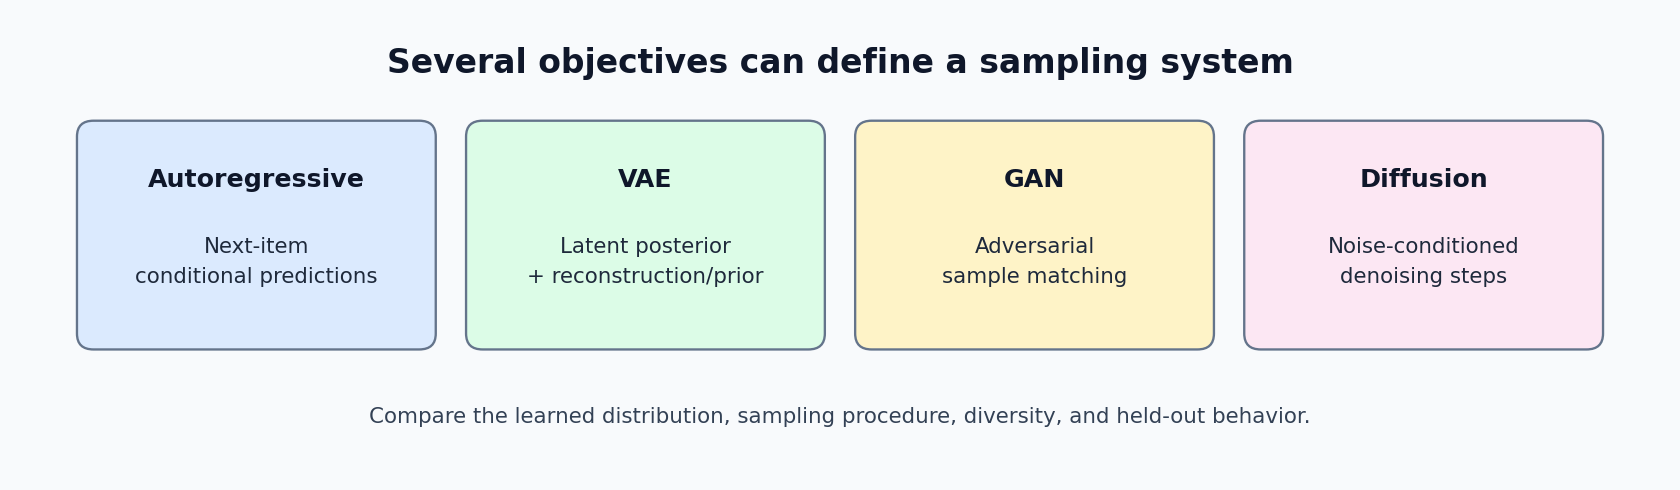

| Family | Training signal | Typical sampling path |
| --- | --- | --- |
| Autoregressive | Next-item conditional likelihood | Produce items sequentially |
| VAE | Reconstruction likelihood surrogate plus latent regularization | Draw a prior latent, then decode |
| GAN | Generator/discriminator objectives | Draw noise, then run the generator |
| Diffusion | Noise-conditioned denoising objective | Start noisy and apply reverse steps |

A plain deterministic autoencoder learns reconstruction and does not, by that fact alone, define useful samples from arbitrary latent codes. A VAE adds a probabilistic latent and prior-related objective.

Not every generative family supplies a tractable normalized likelihood for an observation. A GAN can define a sampling distribution implicitly through its generator without computing a pointwise density. The available evaluation and training quantities therefore differ.

The following lessons inspect [Autoencoders and VAEs](38_Autoencoders_and_VAEs_Notes.ipynb), [GANs](39_GANs_Notes.ipynb), and [Diffusion Models](40_Diffusion_Models_Notes.ipynb) through their own concrete computations.


## Distinguish conditional generation from choosing a random regime

An unconditional sampler draws $x\sim p_\theta(x)$. A conditional sampler draws $x\sim p_\theta(x\mid c)$, where the supplied condition might be a category, input representation, or source observation.

For the known mixture, supplying component zero means drawing around -2 without first selecting the 30/70 mixture. Supplying component one means drawing around two. Randomly choosing the component creates the unconditional marginal distribution.

| Setting | Condition source | What should be evaluated? |
| --- | --- | --- |
| Unconditional mixture | Internally sampled component | Overall weights and component shapes |
| Fixed component request | Supplied component ID | Conditional mean and variation |
| Learned semantic condition | Labeled or paired training data | Condition adherence and sample diversity |

A text prompt or class label does not automatically give meaning to an untrained network. The system must learn or be designed to connect that condition to output behavior. Evaluate condition-following separately from whether samples look plausible in isolation.

A strong aggregate score can hide that one requested condition fails much more often than another.


## Show why a few moments cannot establish the full distribution

The mixture has mean 0.8 and variance 3.61. A single Gaussian with mean 0.8 and standard deviation 1.9 has those same moments, yet it concentrates much more probability between the mixture's two peaks.

| Candidate sampler | Mean | Variance | Missing information |
| --- | --- | --- | --- |
| Correct mixture | 0.8 | 3.61 | Reference structure |
| Constant output 0.8 | 0.8 | 0 | All variation |
| Single Gaussian with matching moments | 0.8 | 3.61 | Two-regime shape |

Matching a mean is especially weak evidence, but even mean plus variance does not characterize an arbitrary distribution. A model might also match common modes while omitting less frequent ones.

Inspect density or histograms, quantiles, component or subgroup coverage when identifiable, and task-relevant relationships. In high-dimensional data, visual inspection alone is insufficient too: a few chosen examples may conceal repetition or systematic failures.

Sampling quality is a collection of questions about the distribution and intended use, rather than one number that always summarizes it.


## Evaluate learned generation on independent data and fresh samples

Training loss asks how the optimization objective behaves on its examples. Held-out likelihood, when available and appropriate, asks about unseen observations. Generated-sample evaluation asks about outputs from the sampler. These forms of evidence address different parts of the system.

| Evaluation question | Useful evidence |
| --- | --- |
| Are outputs plausible? | Representative sample inspection and task measures |
| Is variation represented? | Coverage, spread, subgroup and mode checks |
| Does a condition control the output? | Conditional comparisons on held-out requests |
| Are outputs overly close to training examples? | Similarity and duplicate analysis under a defined protocol |
| Does the sampler match known statistics? | Independent numerical distribution checks |

Keep model selection separate from final evaluation. If examples share sources, split by the independent source appropriate to the claim. Save sampling settings and random seeds when reproducing an example set.

A seed controls a random run; it does not increase learned quality. A different seed can expose variation but cannot repair a systematically incorrect distribution.


## Interpret the companion and diagnose sampling mistakes

The companion draws 10000 component IDs, selects centers, adds standard-normal noise scaled by 0.5, and checks component fraction and conditional means. No optimizer, learned network, train/test split, or parameter estimation is present.

| Mistake | Consequence | Check |
| --- | --- | --- |
| Reverse Bernoulli/component mapping | Wrong mixture weights | Meaning of component IDs |
| Treat 0.5 as variance in the draw | Wrong spread | Standard deviation versus variance |
| Repeat one noise value for every sample | Dependent or identical variation | Shape and independence of draws |
| Match only the sample mean | Miss wrong spread or modes | Distribution shape and subgroup checks |
| Call a fixed sampler trained | Unsupported learning claim | Locate actual parameter updates |

The known sampler is useful because the target distribution is explicit. It allows us to inspect what generation means before adding the uncertainty and optimization challenges of fitting an unknown distribution.


## Practice the mixture and retain the distribution view

1. What is the probability of component zero in the companion?
2. With component mean -2, standard deviation 0.5, and selected noise two, what sample results?
3. Why is the overall standard deviation 1.9 rather than 0.5?
4. Does a generator with mean 0.8 necessarily match this mixture?
5. Does the companion learn any distribution parameters?

**Answers.** Component zero has probability 0.30. The sample is $-2+0.5(2)=-1$. Overall variance includes the separation between component means as well as within-component noise. A matching mean does not establish the right spread or two-mode structure. The companion uses fixed known parameters without fitting them.

**Remember:** generation means sampling from a defined or learned distribution. Individual samples, empirical statistics, learned objectives, and distributional fidelity supply different kinds of evidence.

Continue with [Autoencoders and VAEs](38_Autoencoders_and_VAEs_Notes.ipynb) to learn a latent-variable sampling system from data.
